# t-SNE — Complete Intuition and Practical Guide
## t-distributed Stochastic Neighbour Embedding from First Principles

t-SNE is one of the most powerful dimensionality reduction tools for **visualisation**.  
It takes high-dimensional data and compresses it into 2D or 3D while preserving **local neighbourhood structure**.

This notebook covers:
- The curse of dimensionality and why we need dimensionality reduction
- PCA limitations and why t-SNE was invented
- The t-SNE algorithm step by step (math + intuition)
- Perplexity — the most misunderstood hyperparameter
- The Student-t distribution trick and why it matters
- Full experiments on MNIST digits, Iris, and synthetic data
- Practical do's and don'ts
- t-SNE vs UMAP vs PCA head-to-head


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_digits, make_blobs, make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.stats import t as student_t
from scipy.special import softmax

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})
sns.set_palette("tab10")

print("All libraries loaded.")


All libraries loaded.


## 1. The Curse of Dimensionality

Before understanding t-SNE, you must understand *why* dimensionality reduction is hard.

In high dimensions, counterintuitive things happen:
- Points become **equidistant** — everything is equally far from everything else
- Most of the **volume lives in the corners** of a hypercube, not the centre
- The ratio of max/min pairwise distances collapses to 1

This means standard distance-based algorithms (K-NN, K-Means, visualisation) break down as dimensions increase.


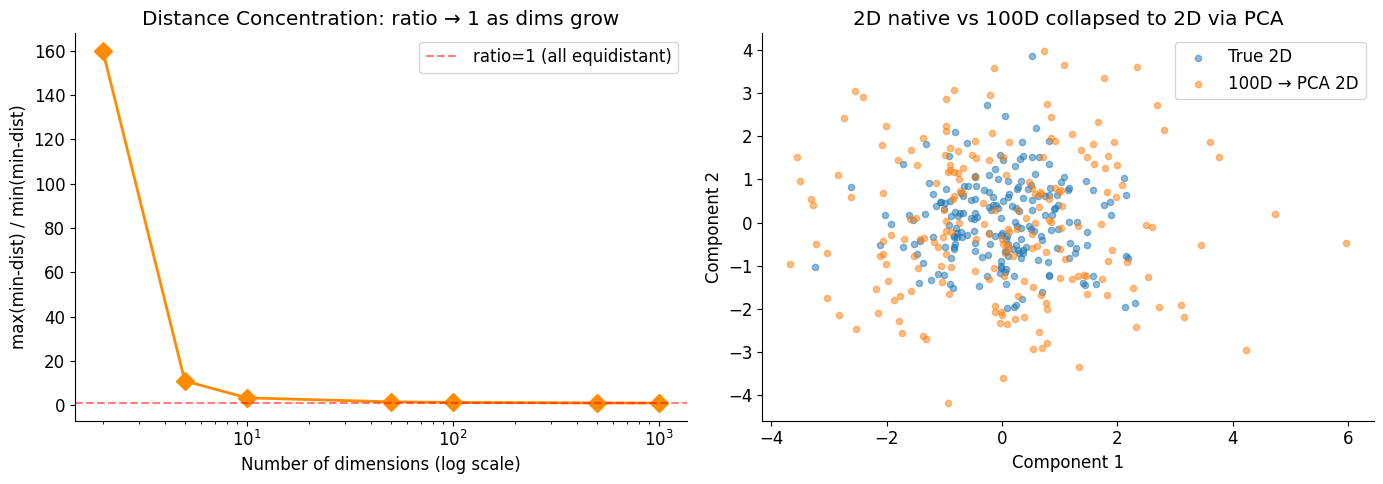

In [2]:
# Demonstrate distance concentration in high dimensions

dims = [2, 5, 10, 50, 100, 500, 1000]
n_samples = 500
ratios = []

for d in dims:
    np.random.seed(0)
    X = np.random.randn(n_samples, d)
    dists = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=-1))
    np.fill_diagonal(dists, np.inf)
    max_d = dists.min(axis=1).max()
    min_d = dists.min(axis=1).min()
    ratios.append(max_d / min_d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].semilogx(dims, ratios, 'D-', color='darkorange', ms=9, lw=2)
axes[0].set_xlabel("Number of dimensions (log scale)")
axes[0].set_ylabel("max(min-dist) / min(min-dist)")
axes[0].set_title("Distance Concentration: ratio → 1 as dims grow")
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='ratio=1 (all equidistant)')
axes[0].legend()

# Visualise point distributions in 2D vs high-D projected to 2D
np.random.seed(42)
X2  = np.random.randn(200, 2)
X100= np.random.randn(200, 100)
pca2 = PCA(n_components=2).fit_transform(X100)

axes[1].scatter(X2[:,0], X2[:,1], alpha=0.5, s=20, label='True 2D', color='tab:blue')
axes[1].scatter(pca2[:,0], pca2[:,1], alpha=0.5, s=20, label='100D → PCA 2D', color='tab:orange')
axes[1].set_title("2D native vs 100D collapsed to 2D via PCA")
axes[1].legend()
axes[1].set_xlabel("Component 1"); axes[1].set_ylabel("Component 2")

plt.tight_layout()
plt.show()


## 2. PCA — Fast But Limited

PCA finds **linear projections** that maximise variance.  
It's fast, deterministic, and great for understanding global structure.

But it has a fundamental limitation: **it can only find linear structure**.  
Nonlinear manifolds — spirals, Swiss rolls, clusters within clusters — are completely invisible to PCA.


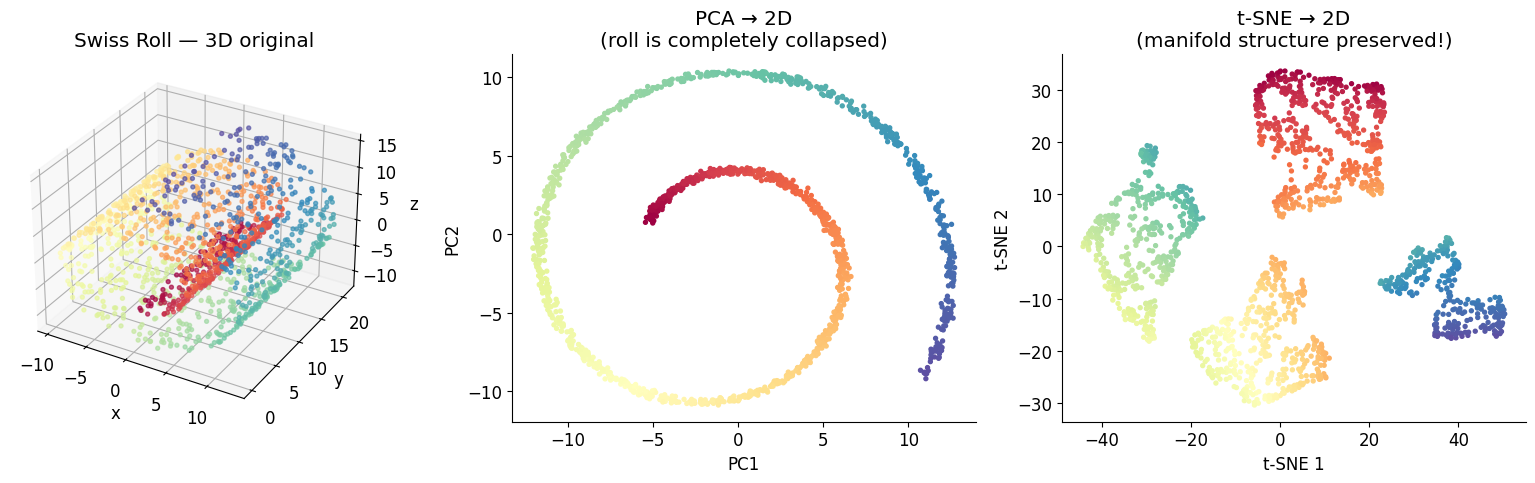

In [3]:
# Swiss roll: PCA fails, we need something better

X_roll, colour_roll = make_swiss_roll(n_samples=1500, noise=0.1, random_state=42)

pca_roll = PCA(n_components=2).fit_transform(X_roll)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_roll[:,0], X_roll[:,1], X_roll[:,2],
            c=colour_roll, cmap='Spectral', s=8, alpha=0.7)
ax1.set_title("Swiss Roll — 3D original")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

ax2 = fig.add_subplot(132)
ax2.scatter(pca_roll[:,0], pca_roll[:,1], c=colour_roll, cmap='Spectral', s=8)
ax2.set_title("PCA → 2D\n(roll is completely collapsed)")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")

# t-SNE unrolls it
tsne_roll = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
X_roll_2d = tsne_roll.fit_transform(X_roll)

ax3 = fig.add_subplot(133)
ax3.scatter(X_roll_2d[:,0], X_roll_2d[:,1], c=colour_roll, cmap='Spectral', s=8)
ax3.set_title("t-SNE → 2D\n(manifold structure preserved!)")
ax3.set_xlabel("t-SNE 1"); ax3.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


## 3. The t-SNE Algorithm — Step by Step

t-SNE works in two phases:

### Phase 1: Build a probability distribution in high-D space
For each pair of points (i, j), compute the **conditional probability** that i would pick j as a neighbour:

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

Then symmetrise: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$

This captures **local neighbourhood structure** — nearby points get high probability, distant points get near-zero.

### Phase 2: Build a probability distribution in 2D space
In the low-dimensional embedding, use a **Student-t distribution** (heavy tails):

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

### Phase 3: Minimise the KL divergence
Optimise the 2D positions $y_i$ to make Q as similar to P as possible:

$$KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

This is done via **gradient descent** with momentum.


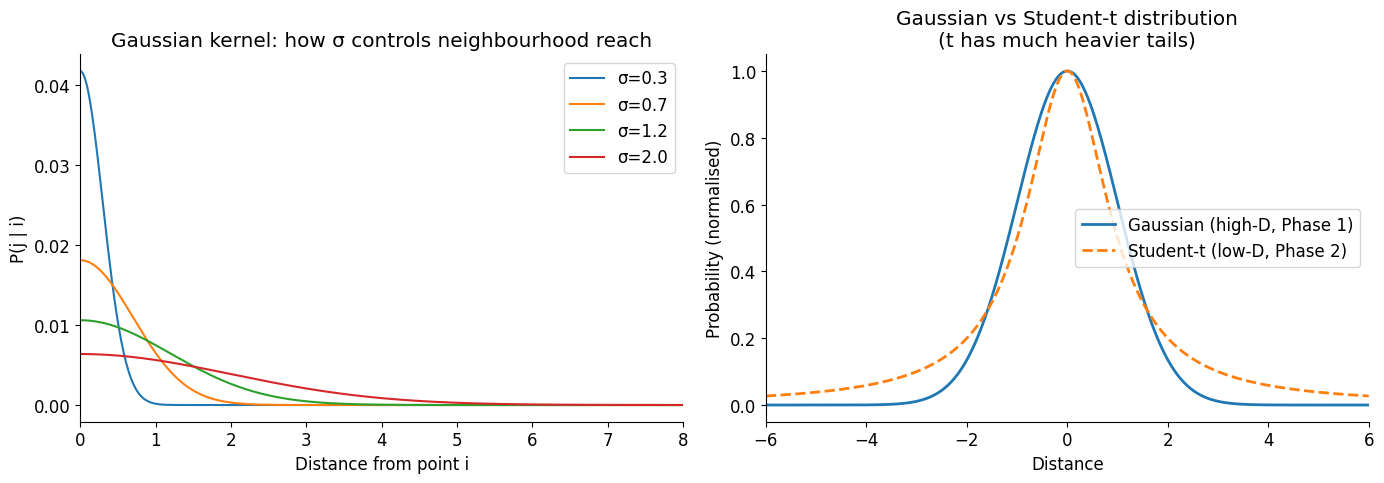

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Visualise the Gaussian kernel (Phase 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0, 8, 500)
for sigma in [0.3, 0.7, 1.2, 2.0]:
    p = np.exp(-x**2 / (2 * sigma**2))
    p /= p.sum()
    axes[0].plot(x, p, label=f'σ={sigma}')

axes[0].set_title("Gaussian kernel: how σ controls neighbourhood reach")
axes[0].set_xlabel("Distance from point i")
axes[0].set_ylabel("P(j | i)")
axes[0].legend()
axes[0].set_xlim(0, 8)

# Compare Gaussian vs Student-t tails
x2 = np.linspace(-6, 6, 500)
gaussian = np.exp(-x2**2 / 2)
student  = (1 + x2**2) ** (-1)

axes[1].plot(x2, gaussian / gaussian.max(), label='Gaussian (high-D, Phase 1)', lw=2)
axes[1].plot(x2, student  / student.max(),  label='Student-t (low-D, Phase 2)', lw=2, linestyle='--')

axes[1].set_title("Gaussian vs Student-t distribution\n(t has much heavier tails)")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Probability (normalised)")
axes[1].legend()
axes[1].set_xlim(-6, 6)

plt.tight_layout()
plt.show()

## 4. Why the Student-t Distribution Matters

This is the single most important insight in t-SNE.

**The problem with Gaussian in 2D**: In high-dimensional space, many moderately-distant points accumulate.  
When we try to map them to 2D, there simply isn't enough room — everything gets squeezed together.

**The solution**: Use a distribution with **heavier tails** in the low-D map.  
The Student-t (with 1 degree of freedom = Cauchy distribution) allows moderately-distant clusters to be pushed **further apart** in 2D than their high-D distances would suggest.

Result: **clusters get clearly separated** even when they're just "moderately" separated in high-D.


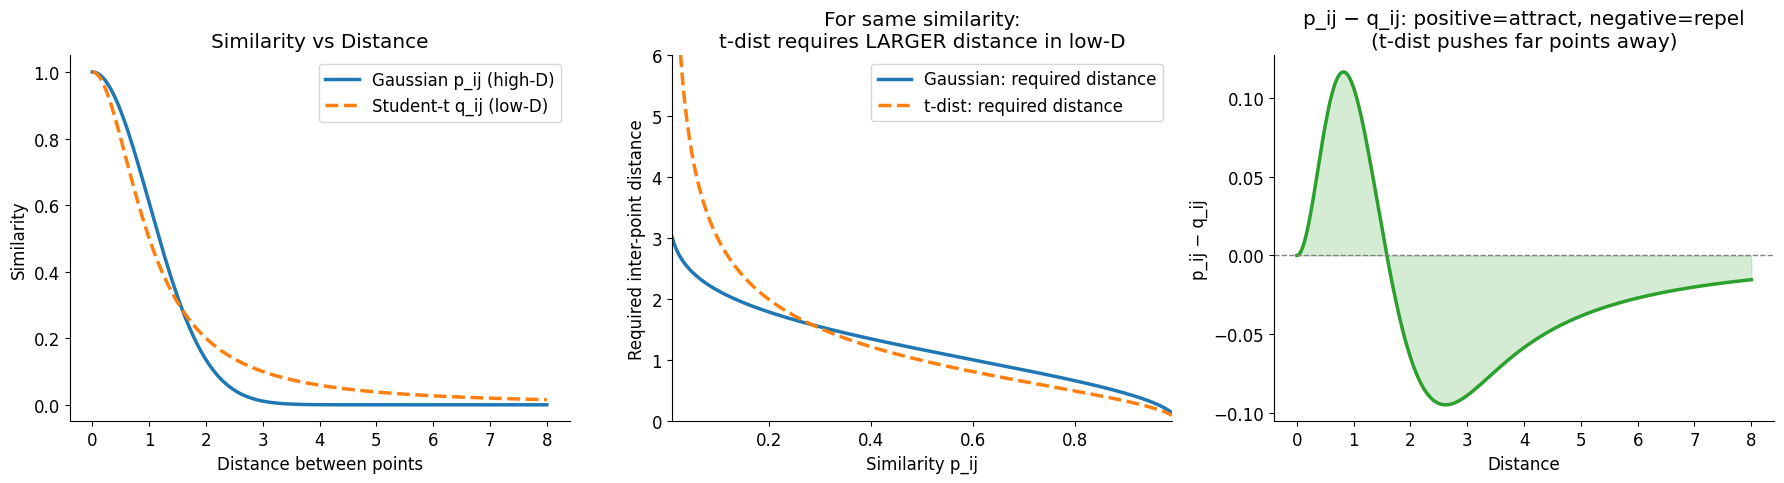

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Visualise the crowding problem and how t-distribution solves it

np.random.seed(0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# High-dim: points at many different distances
n = 100
distances_hd = np.sort(np.random.exponential(scale=2, size=n))

d_range = np.linspace(0, 8, 500)

# Gaussian pairwise similarity
p_gauss = np.exp(-d_range**2 / 2)
# Student-t pairwise similarity
q_t = 1 / (1 + d_range**2)

axes[0].plot(d_range, p_gauss, lw=2.5, color='tab:blue', label='Gaussian p_ij (high-D)')
axes[0].plot(d_range, q_t, lw=2.5, color='tab:orange', linestyle='--', label='Student-t q_ij (low-D)')
axes[0].set_title("Similarity vs Distance")
axes[0].set_xlabel("Distance between points")
axes[0].set_ylabel("Similarity")
axes[0].legend()

# For same similarity value, what distance does each distribution predict?
sim_vals = np.linspace(0.01, 0.99, 200)
d_gauss_inv = np.sqrt(-2 * np.log(sim_vals))   # Gaussian → dist
d_t_inv = np.sqrt(1/sim_vals - 1)              # t → dist

axes[1].plot(sim_vals, d_gauss_inv, lw=2.5, color='tab:blue', label='Gaussian: required distance')
axes[1].plot(sim_vals, d_t_inv, lw=2.5, color='tab:orange', linestyle='--', label='t-dist: required distance')

axes[1].set_title("For same similarity:\nt-dist requires LARGER distance in low-D")
axes[1].set_xlabel("Similarity p_ij")
axes[1].set_ylabel("Required inter-point distance")
axes[1].legend()
axes[1].set_xlim(0.01, 0.99)
axes[1].set_ylim(0, 6)

# The repulsion gradient is stronger far from clusters
diff = p_gauss - (q_t / q_t.max()) * p_gauss.max()

axes[2].plot(d_range, diff, lw=2.5, color='tab:green')
axes[2].axhline(0, color='gray', linestyle='--', lw=1)
axes[2].fill_between(d_range, 0, diff, alpha=0.2, color='tab:green')

axes[2].set_title("p_ij − q_ij: positive=attract, negative=repel\n(t-dist pushes far points away)")
axes[2].set_xlabel("Distance")
axes[2].set_ylabel("p_ij − q_ij")

plt.tight_layout()
plt.show()

## 5. Perplexity — The Most Important Hyperparameter

Perplexity controls how many neighbours each point effectively considers.  
It's related to the bandwidth σᵢ of the Gaussian kernel.

**Intuition**: perplexity ≈ the effective number of neighbours.

- **Low perplexity (5–10)**: only very nearby points matter. Reveals fine-grained local clusters but may break apart large clusters.
- **High perplexity (30–50)**: considers a wider neighbourhood. Captures more global structure.
- **Too high (> n/2)**: collapses everything into one blob.

**Rule of thumb**: perplexity between 5 and 50, with 30 as the default starting point.  
Always try multiple values and compare!


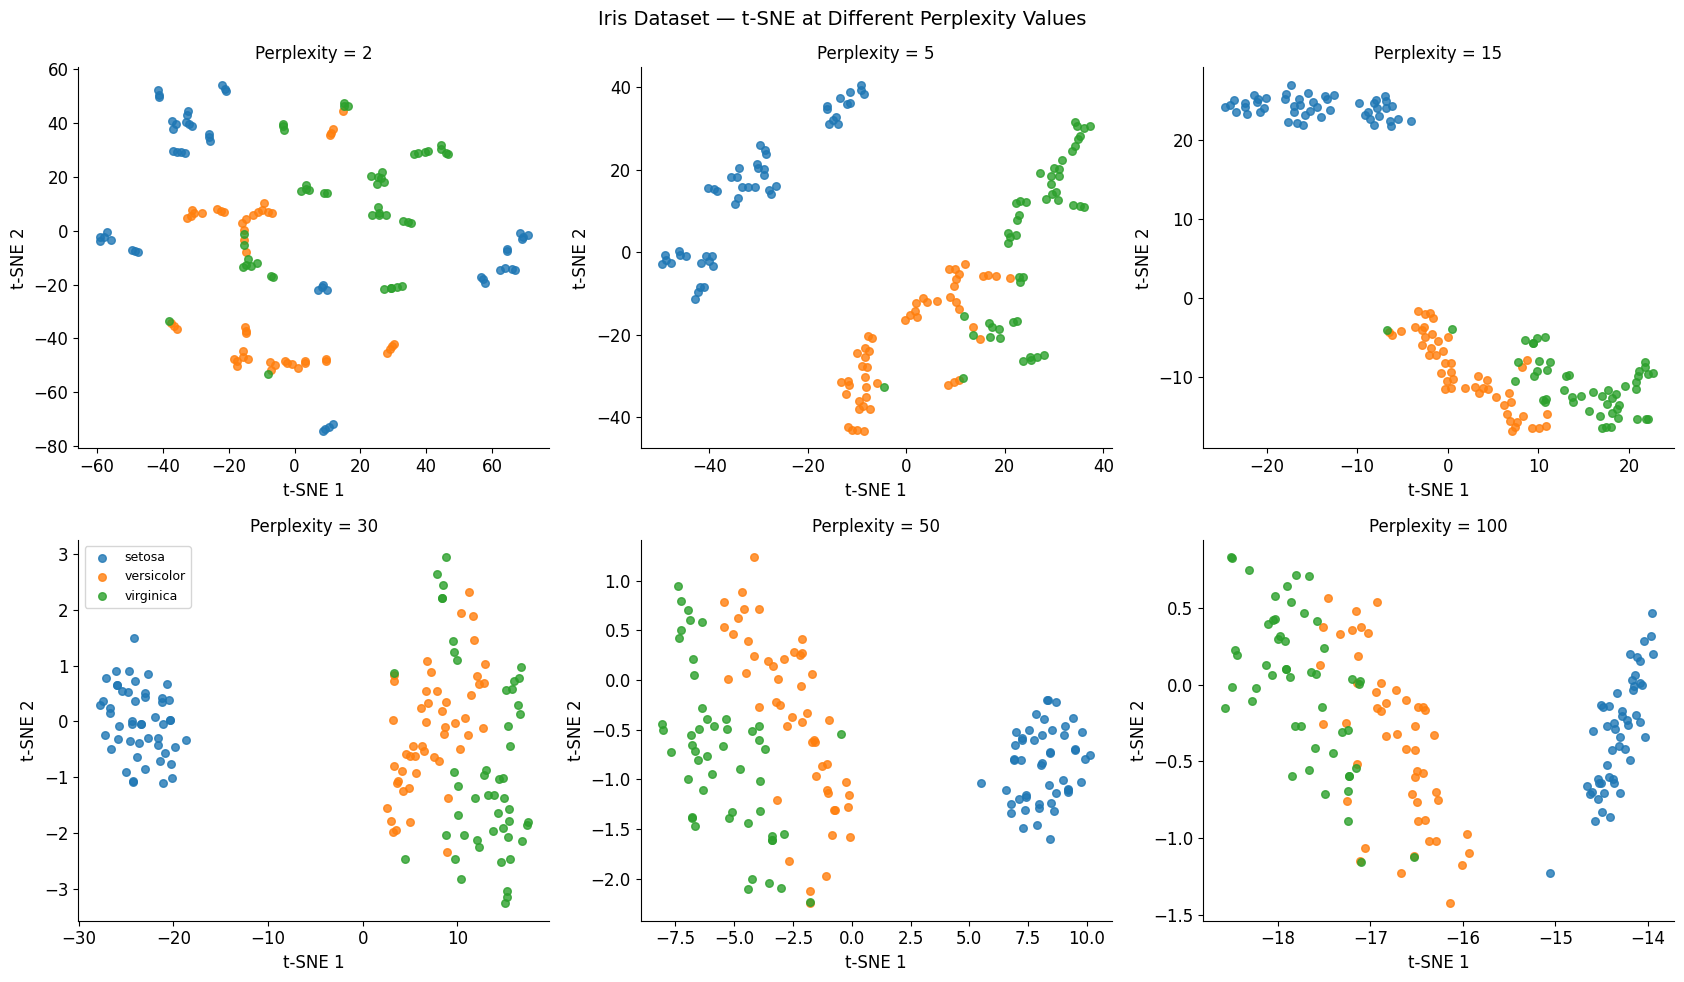

In [6]:
# ===== Imports =====
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ===== Load and preprocess data =====
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target
target_names = iris.target_names

# ===== Perplexity sweep =====
perplexities = [2, 5, 15, 30, 50, 100]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=42,
        max_iter=1000,        # updated param (was n_iter)
        learning_rate='auto',
        init='pca'
    )
    
    X_2d = tsne.fit_transform(X_iris)

    for cls in [0, 1, 2]:
        mask = y_iris == cls
        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=30,
            alpha=0.8,
            label=target_names[cls]
        )

    ax.set_title(f"Perplexity = {perp}", fontsize=12)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    # show legend only once for clarity
    if perp == 30:
        ax.legend(fontsize=9)

# ===== Final layout =====
fig.suptitle("Iris Dataset — t-SNE at Different Perplexity Values", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Perplexity and the Binary Search for σ

t-SNE sets σᵢ for each point individually so that the resulting conditional distribution has the desired perplexity.

Perplexity is defined as:
$$\text{Perp}(P_i) = 2^{H(P_i)}$$

where $H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}$ is the Shannon entropy of the neighbourhood distribution.

t-SNE binary searches for the σᵢ that achieves the target perplexity for each point.  
This means **denser regions get smaller σ** (tight neighbourhood), **sparse regions get larger σ** (wider neighbourhood).  
This adaptive bandwidth is key to why t-SNE handles varying density well.


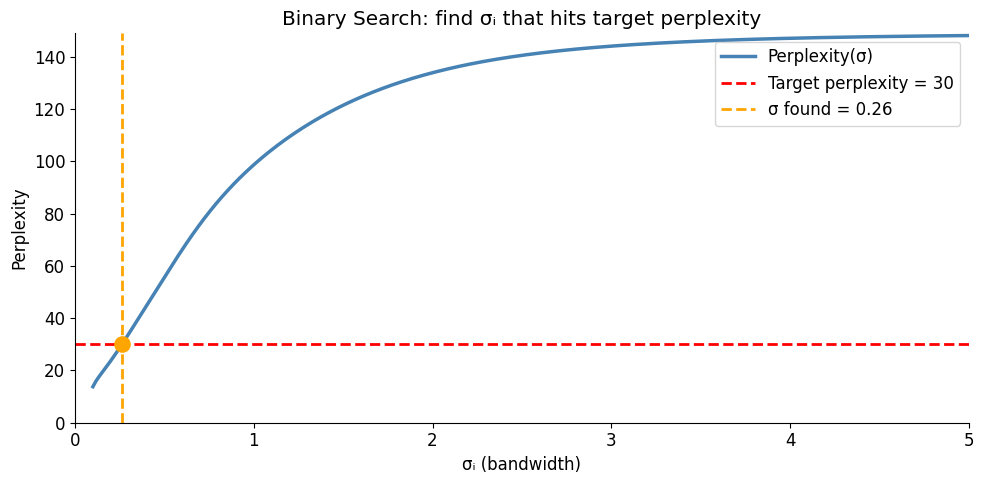

σᵢ = 0.264 produces perplexity ≈ 30.1


In [7]:
# Simulate the binary search for sigma (perplexity matching)

def compute_perplexity(distances_from_i, sigma):
    numerator = np.exp(-distances_from_i**2 / (2 * sigma**2))
    numerator /= numerator.sum()
    entropy = -np.sum(numerator * np.log2(numerator + 1e-12))
    return 2 ** entropy

# For one point, show how sigma controls perplexity
np.random.seed(5)
dists_example = np.sort(np.abs(np.random.randn(149) * 2))  # distances to 149 neighbours
sigmas = np.linspace(0.1, 5.0, 300)
perps  = [compute_perplexity(dists_example, s) for s in sigmas]

target_perp = 30
# find sigma for target perplexity
idx = np.argmin(np.abs(np.array(perps) - target_perp))
sigma_found = sigmas[idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sigmas, perps, lw=2.5, color='steelblue', label='Perplexity(σ)')
ax.axhline(target_perp, color='red', linestyle='--', lw=2, label=f'Target perplexity = {target_perp}')
ax.axvline(sigma_found, color='orange', linestyle='--', lw=2,
           label=f'σ found = {sigma_found:.2f}')
ax.scatter([sigma_found], [target_perp], color='orange', s=120, zorder=5)
ax.set_xlabel("σᵢ (bandwidth)")
ax.set_ylabel("Perplexity")
ax.set_title("Binary Search: find σᵢ that hits target perplexity")
ax.legend()
ax.set_xlim(0, 5)
ax.set_ylim(0, 149)
plt.tight_layout()
plt.show()
print(f"σᵢ = {sigma_found:.3f} produces perplexity ≈ {perps[idx]:.1f}")


## 7. t-SNE on the Digits Dataset

MNIST digits is the classic t-SNE showcase.  
784-dimensional pixel vectors → 2D, and the 10 digit classes clearly separate.

This is impossible with PCA.


Dataset shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]


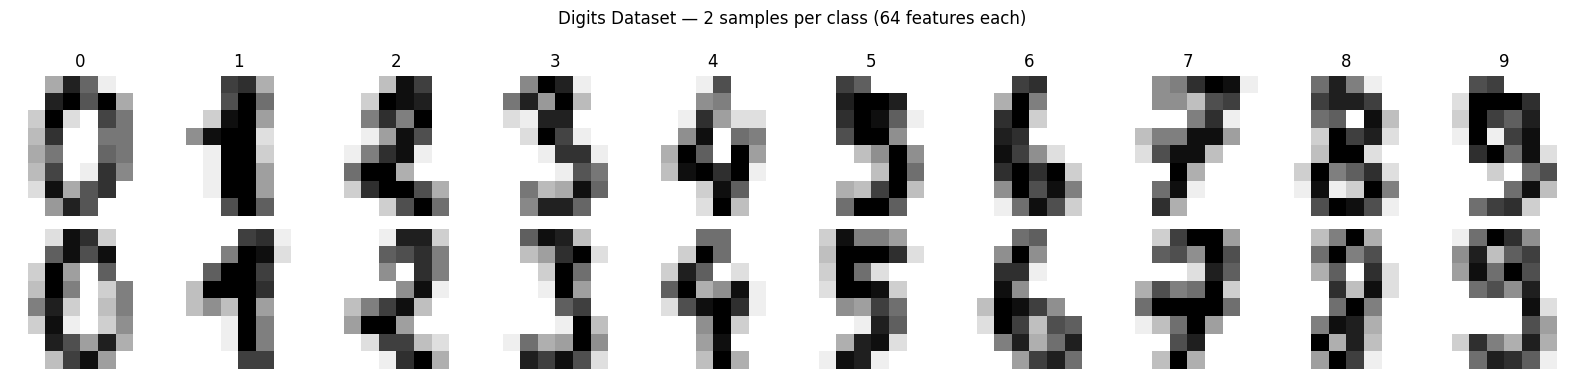

In [8]:
# ===== Imports =====
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

# ===== Load digits dataset =====
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print("Dataset shape:", X_digits.shape)
print("Classes:", np.unique(y_digits))

# ===== Show sample images =====
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for digit in range(10):
    # First sample
    idx = np.where(y_digits == digit)[0][0]
    axes[0][digit].imshow(X_digits[idx].reshape(8, 8), cmap='gray_r')
    axes[0][digit].set_title(str(digit), fontsize=12)
    axes[0][digit].axis('off')

    # Second sample
    idx2 = np.where(y_digits == digit)[0][5]
    axes[1][digit].imshow(X_digits[idx2].reshape(8, 8), cmap='gray_r')
    axes[1][digit].axis('off')

fig.suptitle("Digits Dataset — 2 samples per class (64 features each)", fontsize=12)
plt.tight_layout()
plt.show()

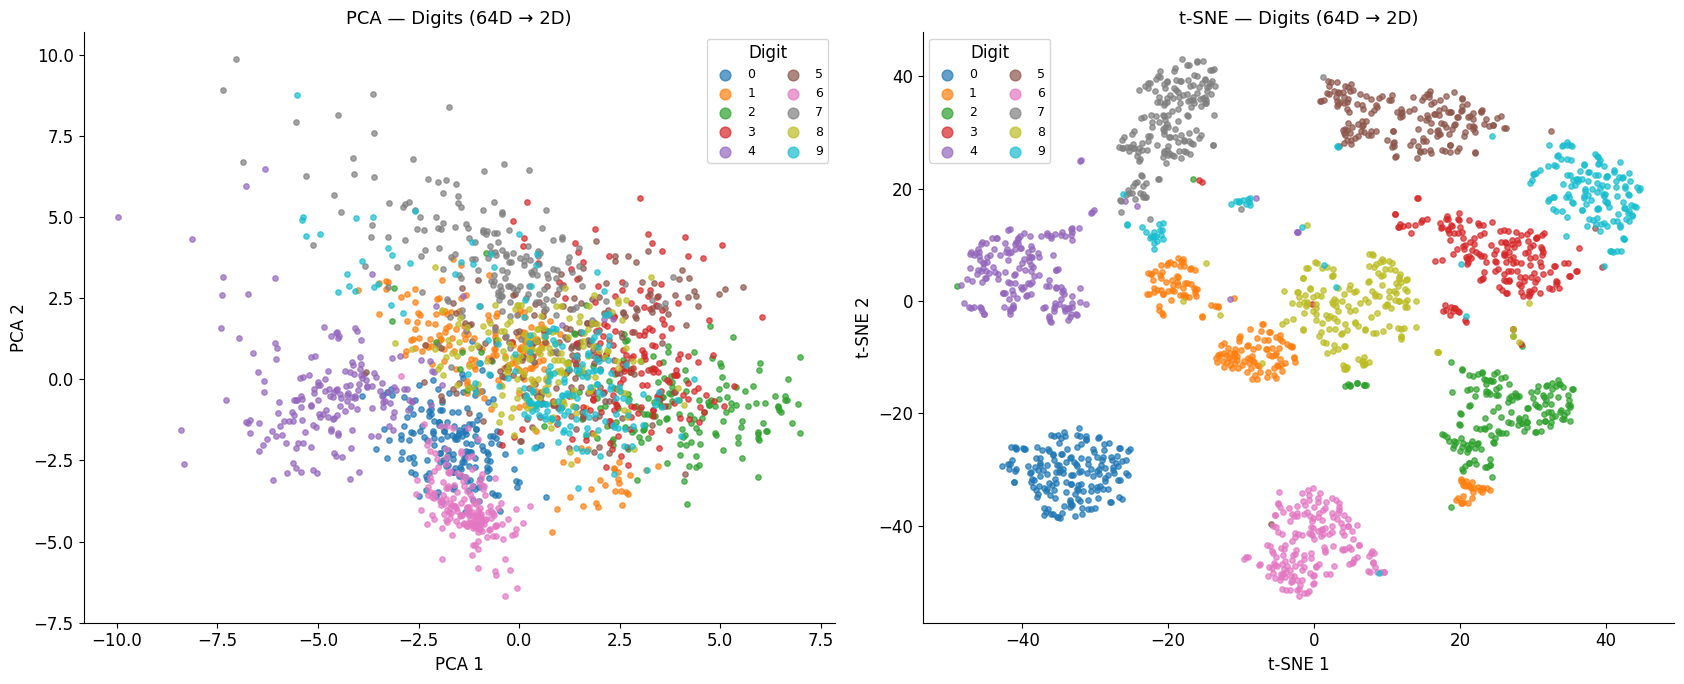

In [9]:
# ===== Imports =====
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ===== Scale data =====
X_digits_scaled = StandardScaler().fit_transform(X_digits)

# ===== PCA =====
pca_digits = PCA(n_components=2, random_state=42)
X_pca_d = pca_digits.fit_transform(X_digits_scaled)

# ===== t-SNE =====
tsne_digits = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    max_iter=1000   # ✅ updated (was n_iter)
)
X_tsne_d = tsne_digits.fit_transform(X_digits_scaled)

# ===== Plot =====
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
cmap = plt.cm.get_cmap('tab10', 10)

for method_name, X_2d, ax in zip(['PCA', 't-SNE'], [X_pca_d, X_tsne_d], axes):
    for digit in range(10):
        mask = y_digits == digit
        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            c=[cmap(digit)],
            s=15,
            alpha=0.7,
            label=str(digit)
        )

    ax.set_title(f"{method_name} — Digits (64D → 2D)", fontsize=13)
    ax.set_xlabel(f"{method_name} 1")
    ax.set_ylabel(f"{method_name} 2")
    ax.legend(title='Digit', loc='best', fontsize=9, markerscale=2, ncol=2)

plt.tight_layout()
plt.show()

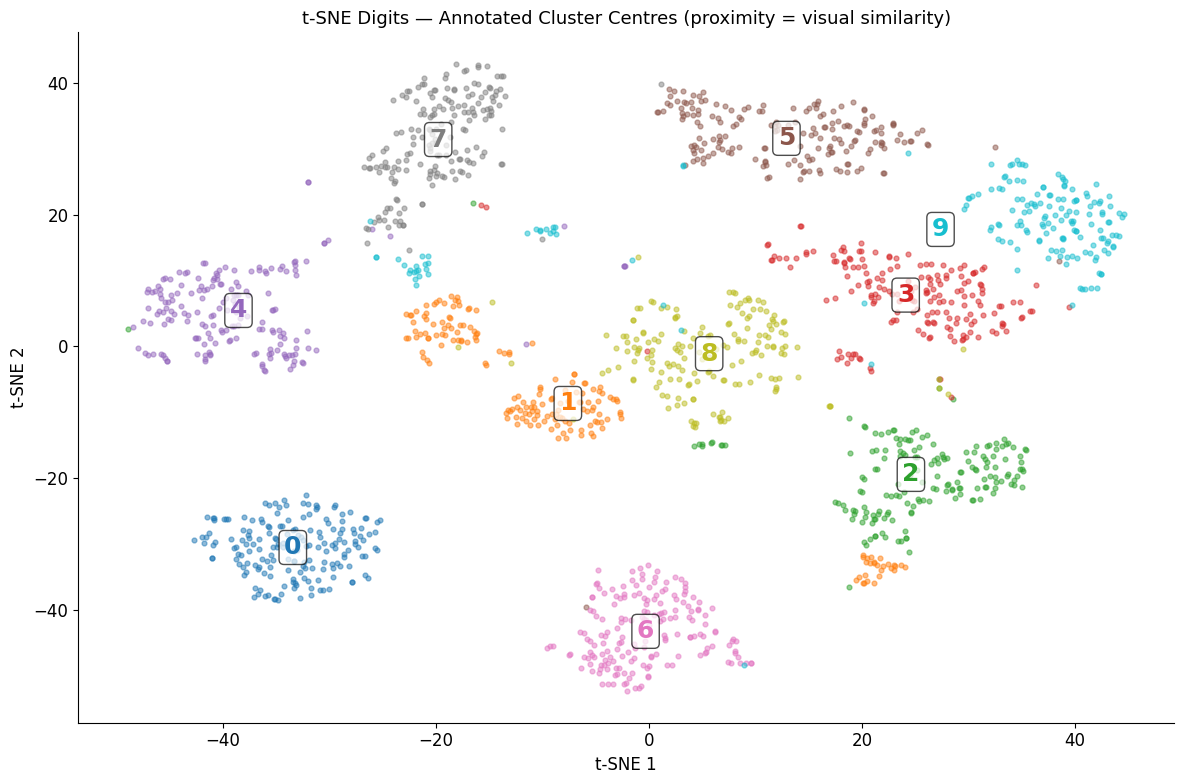

In [11]:
import matplotlib.pyplot as plt
# Note: The following variables are assumed to be defined elsewhere in your code:
# y_digits: The labels for the digits.
# X_tsne_d: The 2D t-SNE projection of your data.
# cmap: A matplotlib colormap (e.g., cmap = plt.get_cmap('tab10')).

# --- Start of your corrected code ---

fig, ax = plt.subplots(figsize=(12, 8))

for digit in range(10):
    mask = y_digits == digit
    x_mean = X_tsne_d[mask, 0].mean()
    y_mean = X_tsne_d[mask, 1].mean()
    ax.scatter(X_tsne_d[mask, 0], X_tsne_d[mask, 1],
               c=[cmap(digit)], s=12, alpha=0.5)
    ax.text(x_mean, y_mean, str(digit), fontsize=18, fontweight='bold',
            color=cmap(digit), ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# FIX: The title string was combined into a single line to resolve the SyntaxError.
ax.set_title("t-SNE Digits — Annotated Cluster Centres (proximity = visual similarity)",
             fontsize=13)

# IMPROVEMENT: Placed axis label calls on separate lines for better readability.
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


## 8. Iterations and Convergence

t-SNE runs gradient descent for a fixed number of iterations.  
In the **early exaggeration phase** (first ~250 iterations), the P values are multiplied by 12  
to encourage tight cluster formation early on.

After that, normal gradient descent with momentum minimises the KL divergence.

You can watch the embedding evolve: it starts noisy, then clusters crystallise.

**Important**: 1000 iterations is a minimum. For large datasets, use 2000–5000.


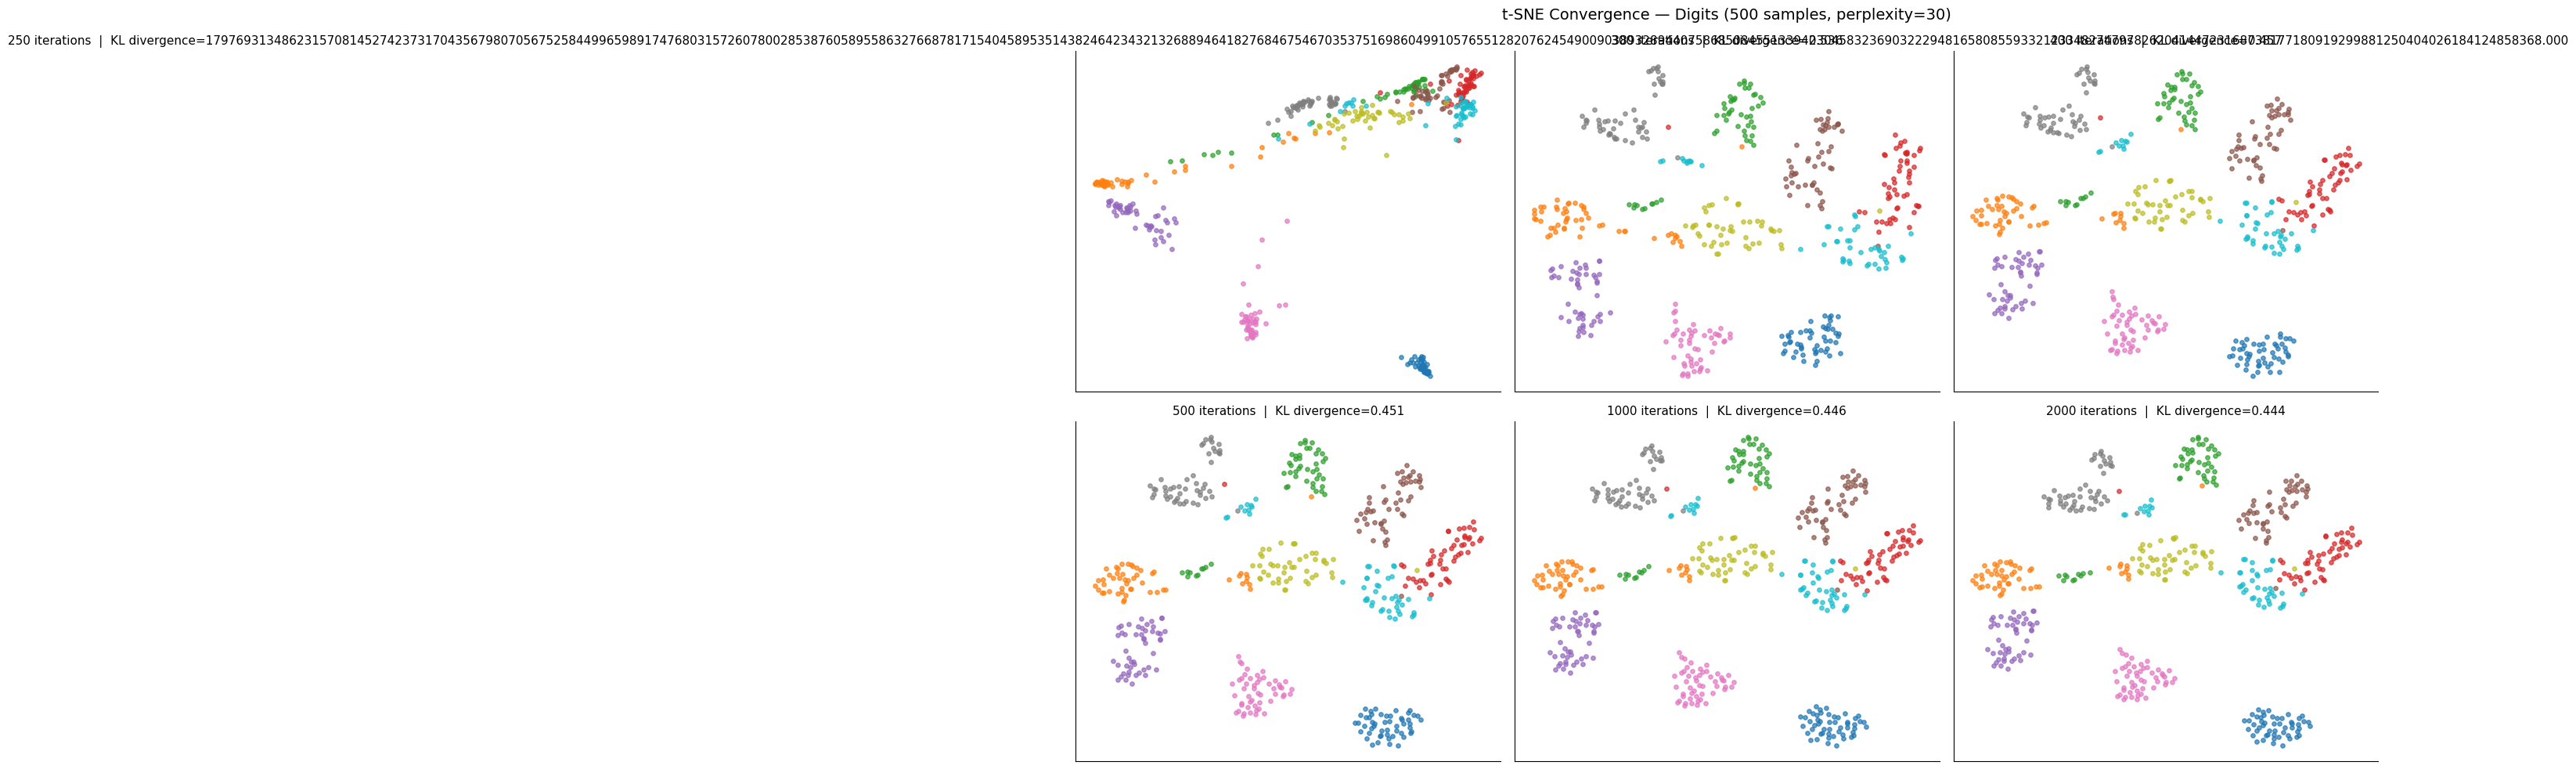

In [14]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# Note: The following variables are assumed to be defined elsewhere in your code:
# X_digits_scaled: The scaled feature data for the digits.
# y_digits: The labels for the digits.
# cmap: A matplotlib colormap (e.g., cmap = plt.get_cmap('tab10')).

# --- Start of your corrected code ---

# FIX: Updated the iteration steps to meet the minimum requirement of 250.
# This still allows us to see how the embedding evolves from the earliest possible point.
iter_steps = [250, 300, 400, 500, 1000, 2000]
X_sub = X_digits_scaled[:500]   # use 500 samples for speed
y_sub = y_digits[:500]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for ax, n_iter in zip(axes, iter_steps):
    # The TSNE class is initialized inside the loop with the new n_iter value
    tsne_iter = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                     init='pca', random_state=42, n_iter=n_iter)
    X_iter = tsne_iter.fit_transform(X_sub)

    for digit in range(10):
        mask = y_sub == digit
        ax.scatter(X_iter[mask, 0], X_iter[mask, 1],
                   c=[cmap(digit)], s=15, alpha=0.7)

    ax.set_title(f"{n_iter} iterations  |  KL divergence={tsne_iter.kl_divergence_:.3f}", fontsize=11)
    # IMPROVEMENT: Using set_xticks([]) is a more standard way to remove ticks.
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("t-SNE Convergence — Digits (500 samples, perplexity=30)", fontsize=14)
plt.tight_layout()
plt.show()


## 9. Learning Rate and Its Effect

Learning rate controls the step size during gradient descent.

- **Too small**: embedding barely moves, clusters don't separate
- **Too large**: points fly apart, unstable embedding, clusters explode
- **sklearn default ('auto')**: learning_rate = n / early_exaggeration (usually good)

For most use cases, leave it at `'auto'`. Only tune if the embedding looks collapsed or exploded.


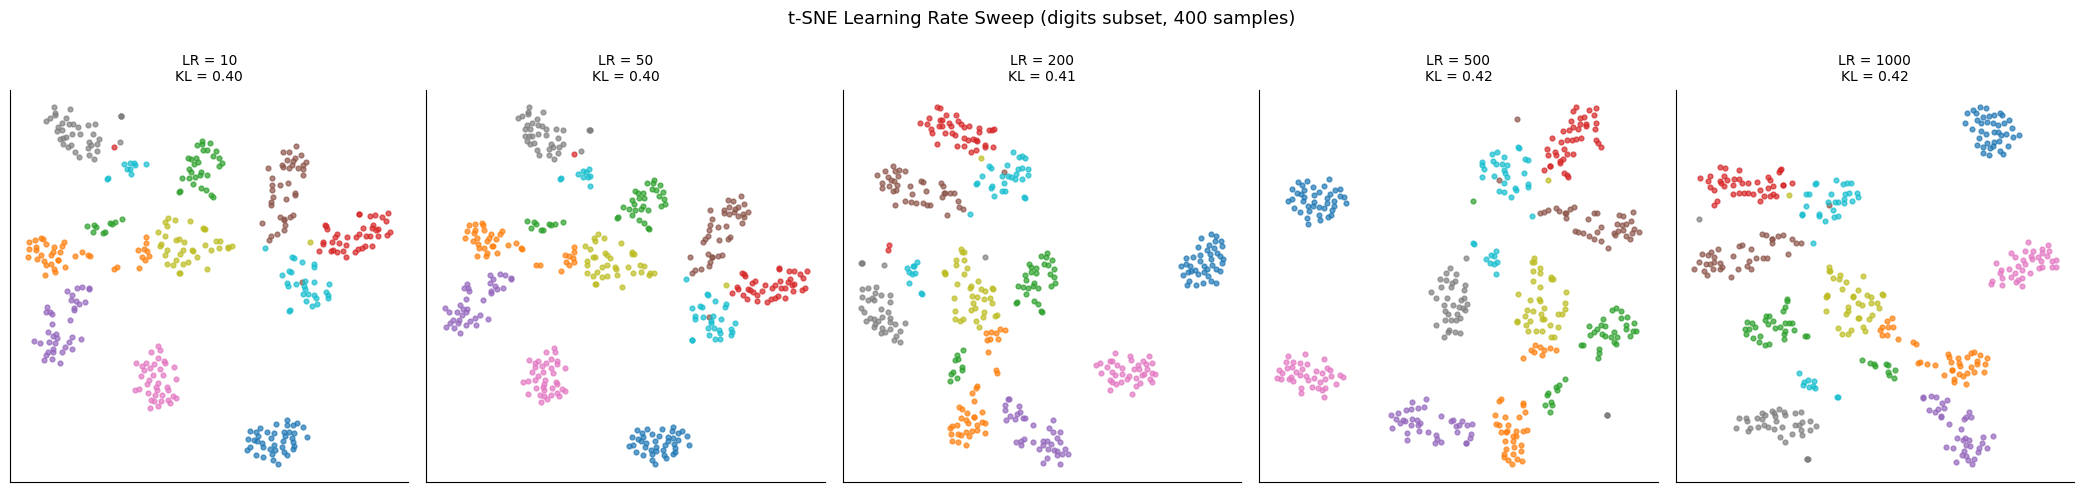

In [16]:
# Learning rate sweep

lr_values = [10, 50, 200, 500, 1000]
X_lr = X_digits_scaled[:400]
y_lr = y_digits[:400]

fig, axes = plt.subplots(1, 5, figsize=(21, 5))

for ax, lr in zip(axes, lr_values):
    tsne_lr = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=lr,
        init='pca',
        random_state=42,
        max_iter=1000   # ✅ updated (was n_iter)
    )
    
    X_lr_2d = tsne_lr.fit_transform(X_lr)

    for digit in range(10):
        mask = y_lr == digit
        ax.scatter(
            X_lr_2d[mask, 0],
            X_lr_2d[mask, 1],
            c=[cmap(digit)],
            s=12,
            alpha=0.7
        )

    # ✅ FIXED: use \n for new line in f-string
    ax.set_title(f"LR = {lr}\nKL = {tsne_lr.kl_divergence_:.2f}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("t-SNE Learning Rate Sweep (digits subset, 400 samples)", fontsize=13)
plt.tight_layout()
plt.show()

## 10. t-SNE Initialisation: Random vs PCA

The starting point of the gradient descent affects the final embedding.

- **Random init**: pure noise → may produce different layouts each run (same seed = same result)
- **PCA init**: initialise using the first 2 PCA components → faster convergence, more stable, recommended

Always use `init='pca'` unless you have a good reason not to.


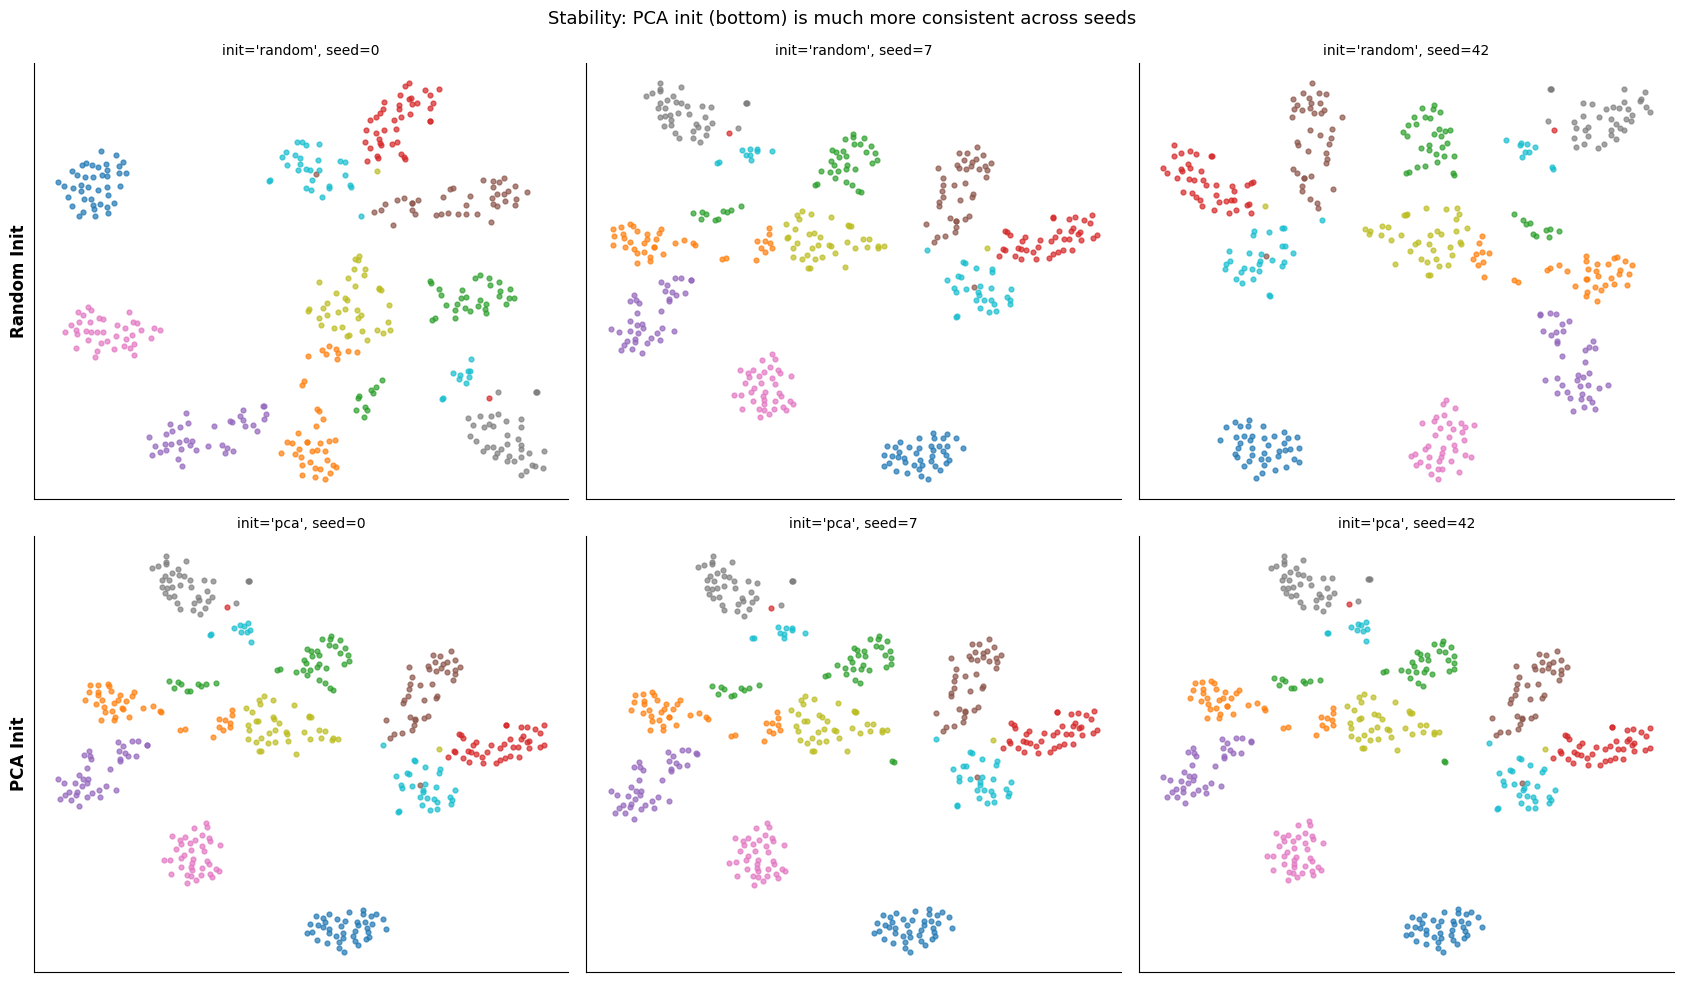

In [17]:
# PCA init vs random init — stability comparison (different seeds)

X_init = X_digits_scaled[:400]
y_init = y_digits[:400]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for col, seed in enumerate([0, 7, 42]):
    for row, init in enumerate(['random', 'pca']):
        tsne_i = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                      init=init, random_state=seed, n_iter=1000)
        X_i = tsne_i.fit_transform(X_init)
        for digit in range(10):
            mask = y_init == digit
            axes[row][col].scatter(X_i[mask, 0], X_i[mask, 1],
                                   c=[cmap(digit)], s=12, alpha=0.7)
        axes[row][col].set_title(f"init='{init}', seed={seed}", fontsize=10)
        axes[row][col].set_xticks([]); axes[row][col].set_yticks([])

axes[0][0].set_ylabel("Random Init", fontsize=12, fontweight='bold')
axes[1][0].set_ylabel("PCA Init", fontsize=12, fontweight='bold')
fig.suptitle("Stability: PCA init (bottom) is much more consistent across seeds", fontsize=13)
plt.tight_layout()
plt.show()


## 11. What t-SNE Preserves vs Distorts

t-SNE is designed to preserve **local structure** (nearby neighbours).  
It makes **no guarantee** about global distances.

### What you CAN trust in a t-SNE plot:
- Points in the same cluster are genuinely similar in the original space
- Two clusters that touch or overlap are probably similar
- Sub-structure within a cluster is real

### What you CANNOT trust:
- **Cluster sizes** are meaningless — denser clusters appear smaller
- **Distances between clusters** are meaningless — t-SNE distorts global distances
- **Cluster shape** is meaningless — the algorithm can produce any shape
- **Same embedding on different runs** (unless same seed)


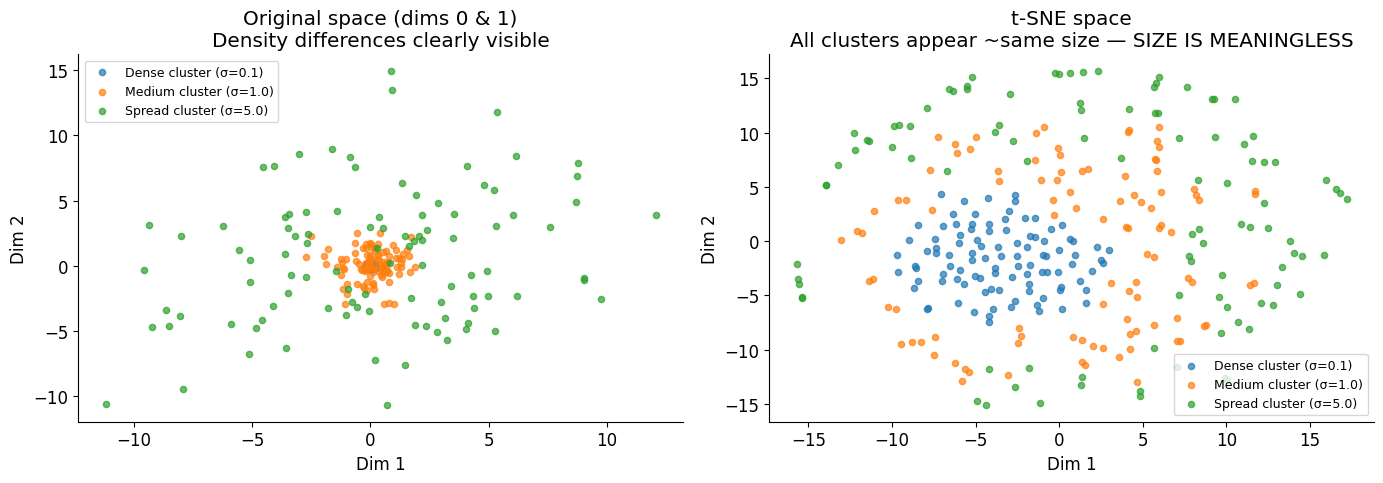

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Demonstrate: cluster sizes in t-SNE are NOT meaningful

np.random.seed(42)

# Create 3 clusters: same number of points, very different densities
X_dense  = np.random.randn(100, 10) * 0.1   # very compact
X_medium = np.random.randn(100, 10) * 1.0   # medium spread
X_spread = np.random.randn(100, 10) * 5.0   # very spread out

X_combined = np.vstack([X_dense, X_medium, X_spread])
y_combined = np.array([0]*100 + [1]*100 + [2]*100)

# t-SNE
tsne_size = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    random_state=42,
    max_iter=1000   # ✅ updated
)

X_size_2d = tsne_size.fit_transform(X_combined)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_s = ['tab:blue', 'tab:orange', 'tab:green']
labels_s = [
    'Dense cluster (σ=0.1)',
    'Medium cluster (σ=1.0)',
    'Spread cluster (σ=5.0)'
]

for cls in range(3):
    mask = y_combined == cls
    
    # Original space
    axes[0].scatter(
        X_combined[mask, 0], X_combined[mask, 1],
        c=colors_s[cls], label=labels_s[cls], s=20, alpha=0.7
    )
    
    # t-SNE space
    axes[1].scatter(
        X_size_2d[mask, 0], X_size_2d[mask, 1],
        c=colors_s[cls], label=labels_s[cls], s=20, alpha=0.7
    )

# ✅ FIXED titles
axes[0].set_title("Original space (dims 0 & 1)\nDensity differences clearly visible")
axes[1].set_title("t-SNE space\nAll clusters appear ~same size — SIZE IS MEANINGLESS")

for ax in axes:
    ax.legend(fontsize=9)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

## 12. t-SNE vs PCA vs UMAP — Full Comparison

| Property | PCA | t-SNE | UMAP |
|----------|-----|-------|------|
| Type | Linear | Non-linear | Non-linear |
| Speed | Very fast | Slow (O(n² log n)) | Faster than t-SNE |
| Preserves | Global structure | Local structure | Local + some global |
| Deterministic | Yes | No (seed-dependent) | No (seed-dependent) |
| New point transform | Yes | No | Yes (approx) |
| Scalable | Yes | Poor beyond 50K | Better |
| Best for | Feature selection, preprocessing | Visualisation of clusters | Visualisation + downstream use |


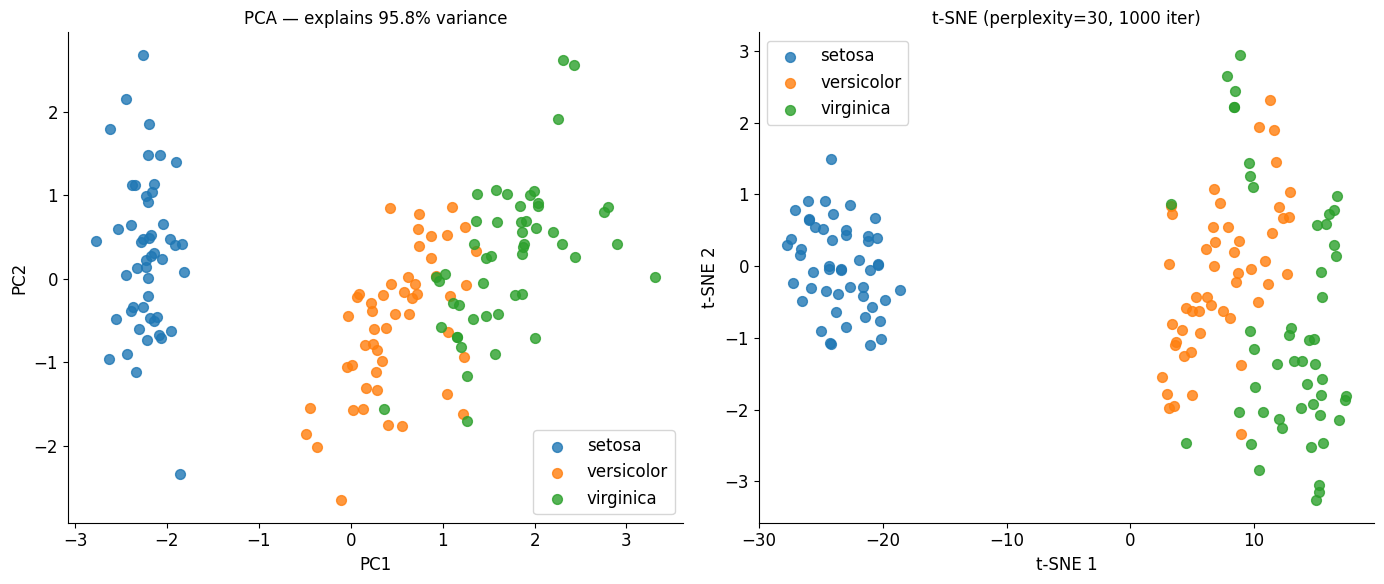

In [20]:
# PCA vs t-SNE on Iris — side by side

iris = load_iris()
X_i = StandardScaler().fit_transform(iris.data)
y_i = iris.target
tnames = iris.target_names

pca_2d = PCA(n_components=2).fit_transform(X_i)
tsne_2d = TSNE(n_components=2, perplexity=30, init='pca', random_state=42, n_iter=1000).fit_transform(X_i)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cls in range(3):
    mask = y_i == cls
    axes[0].scatter(pca_2d[mask, 0], pca_2d[mask, 1], label=tnames[cls], s=50, alpha=0.8)
    axes[1].scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], label=tnames[cls], s=50, alpha=0.8)

axes[0].set_title(f"PCA — explains {PCA(n_components=2).fit(X_i).explained_variance_ratio_.sum()*100:.1f}% variance", fontsize=12)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

axes[1].set_title("t-SNE (perplexity=30, 1000 iter)", fontsize=12)
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2"); axes[1].legend()

plt.tight_layout()
plt.show()


## 13. PCA Pre-Processing Before t-SNE

For high-dimensional data (images, text embeddings), always run PCA first:
1. Reduce to 50 dimensions with PCA (removes noise, speeds up t-SNE dramatically)
2. Run t-SNE on the 50 PCA components

This is the **standard pipeline** used in bioinformatics, NLP, and computer vision.


50 PCA components explain 98.3% of variance


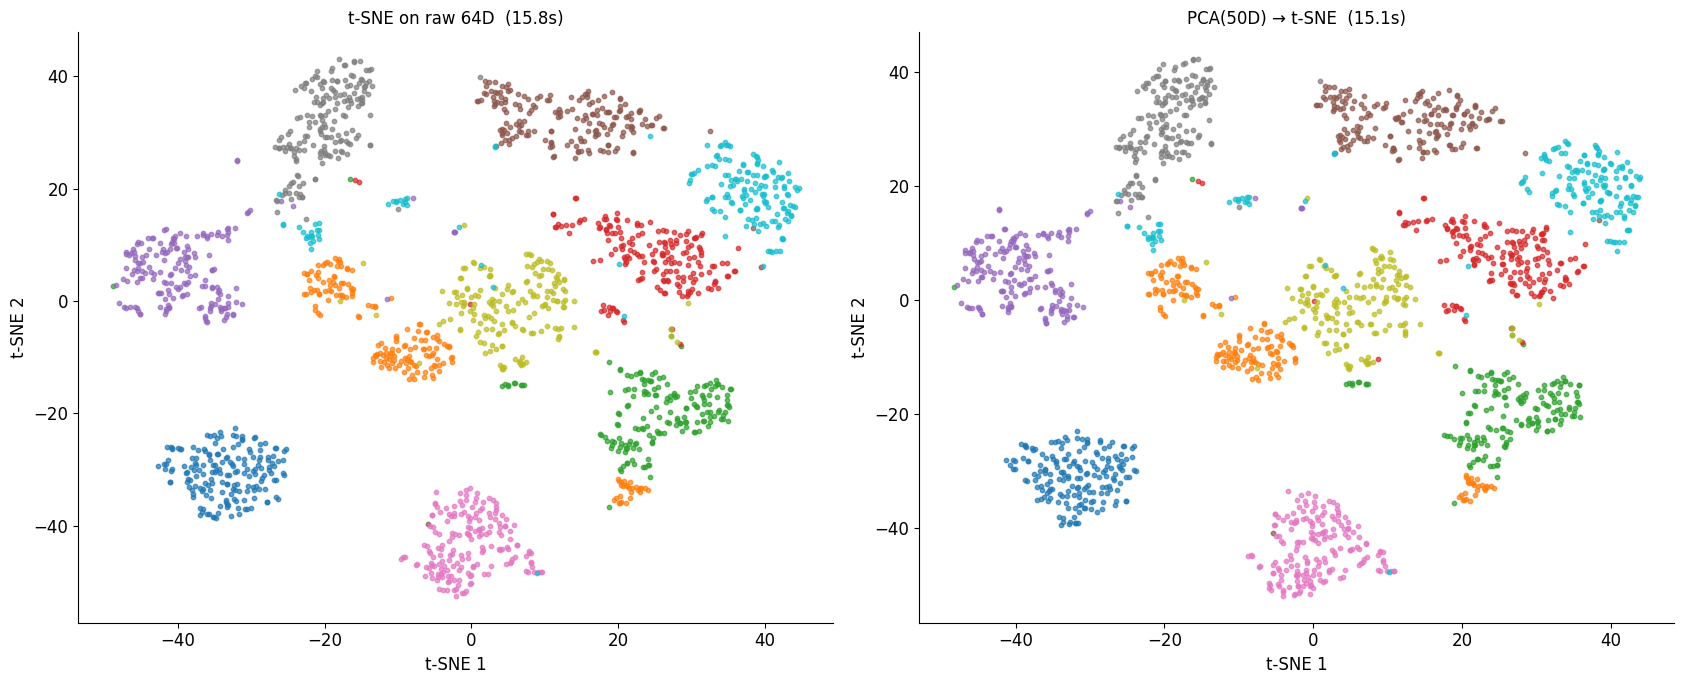

In [21]:
# Compare: t-SNE on raw digits (64D) vs PCA-50 → t-SNE

X_d = StandardScaler().fit_transform(digits.data)
y_d = digits.target

# Full pipeline
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_d)
var_explained = PCA(n_components=50).fit(X_d).explained_variance_ratio_.sum()
print(f"50 PCA components explain {var_explained*100:.1f}% of variance")

import time
t0 = time.time()
tsne_raw = TSNE(n_components=2, perplexity=30, init='pca', random_state=42, n_iter=1000)
X_raw_2d = tsne_raw.fit_transform(X_d)
t1 = time.time()

tsne_pca = TSNE(n_components=2, perplexity=30, init='pca', random_state=42, n_iter=1000)
X_pca_2d = tsne_pca.fit_transform(X_pca50)
t2 = time.time()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for digit in range(10):
    m = y_d == digit
    axes[0].scatter(X_raw_2d[m, 0], X_raw_2d[m, 1], c=[cmap(digit)], s=10, alpha=0.7)
    axes[1].scatter(X_pca_2d[m, 0], X_pca_2d[m, 1], c=[cmap(digit)], s=10, alpha=0.7)

axes[0].set_title(f"t-SNE on raw 64D  ({t1-t0:.1f}s)", fontsize=12)
axes[1].set_title(f"PCA(50D) → t-SNE  ({t2-t1:.1f}s)", fontsize=12)
for ax in axes:
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


## 14. KL Divergence Loss — Monitoring Convergence

t-SNE minimises the KL divergence between P (high-D) and Q (low-D).  
After fitting, `tsne.kl_divergence_` gives you the final loss.

- A well-converged embedding has a stable, low KL divergence
- If the loss is still decreasing when iterations end → increase `n_iter`


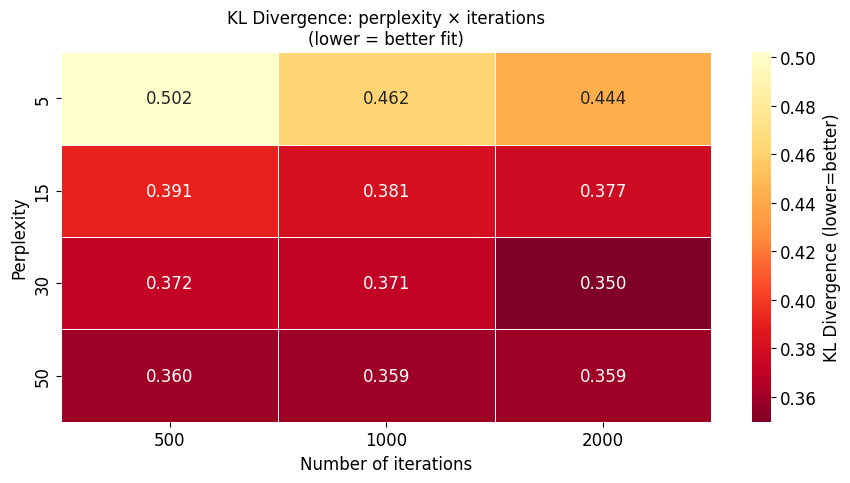

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE

# Monitor KL across perplexities and iterations to find sweet spot

perps_eval = [5, 15, 30, 50]
n_iters_eval = [500, 1000, 2000]

results = []
X_eval_sub = X_digits_scaled[:300]

for perp in perps_eval:
    for n_iter in n_iters_eval:
        tsne_e = TSNE(
            n_components=2,
            perplexity=perp,
            learning_rate='auto',
            init='pca',
            random_state=0,
            max_iter=n_iter   # ✅ FIXED (was n_iter)
        )
        
        tsne_e.fit_transform(X_eval_sub)

        results.append({
            'perplexity': perp,
            'n_iter': n_iter,
            'kl_divergence': tsne_e.kl_divergence_
        })

# Create dataframe
df_kl = pd.DataFrame(results)
pivot = df_kl.pivot(index='perplexity', columns='n_iter', values='kl_divergence')

# Plot heatmap
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd_r',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'KL Divergence (lower=better)'}
)

# ✅ FIXED title
ax.set_title("KL Divergence: perplexity × iterations\n(lower = better fit)", fontsize=12)
ax.set_xlabel("Number of iterations")
ax.set_ylabel("Perplexity")

plt.tight_layout()
plt.show()

## 15. Anomaly Detection with t-SNE

t-SNE can surface anomalies as **isolated points** or **small isolated clusters** that sit far from the main groups.  
This is a qualitative visual tool — not a formal detector — but it's often the fastest way to spot outliers in practice.


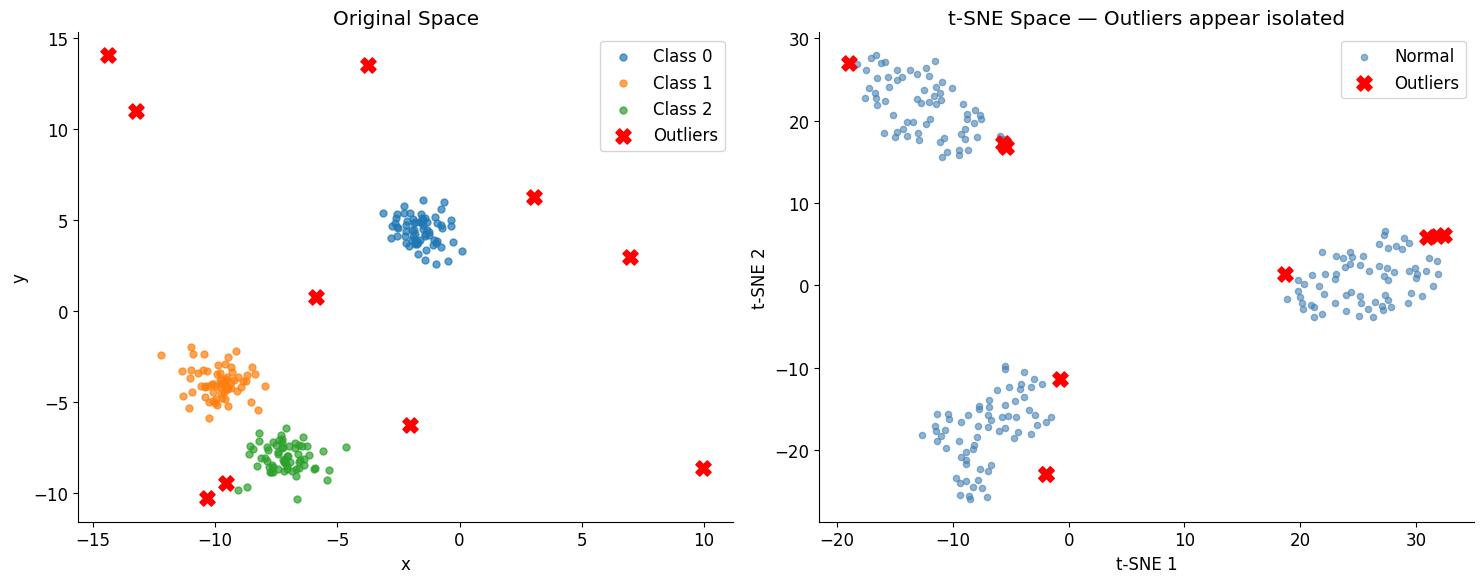

In [24]:
# Inject outliers and watch t-SNE isolate them

np.random.seed(42)
X_normal, y_normal = make_blobs(n_samples=200, centers=3, cluster_std=0.8, random_state=1)
X_outliers = np.random.uniform(low=-15, high=15, size=(10, 2))

X_with_out = np.vstack([X_normal, X_outliers])
is_outlier  = np.array([False]*200 + [True]*10)

X_with_out_s = StandardScaler().fit_transform(X_with_out)
tsne_out = TSNE(n_components=2, perplexity=20, init='pca', random_state=42, n_iter=1000)
X_out_2d = tsne_out.fit_transform(X_with_out_s)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original
for cls in np.unique(y_normal):
    mask = y_normal == cls
    axes[0].scatter(X_normal[mask, 0], X_normal[mask, 1], s=25, alpha=0.7, label=f'Class {cls}')
axes[0].scatter(X_outliers[:,0], X_outliers[:,1], s=120, c='red',
                marker='X', label='Outliers', zorder=5)
axes[0].set_title("Original Space"); axes[0].legend()
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

# t-SNE
axes[1].scatter(X_out_2d[~is_outlier, 0], X_out_2d[~is_outlier, 1],
                c='steelblue', s=20, alpha=0.6, label='Normal')
axes[1].scatter(X_out_2d[is_outlier, 0], X_out_2d[is_outlier, 1],
                c='red', s=120, marker='X', label='Outliers', zorder=5)
axes[1].set_title("t-SNE Space — Outliers appear isolated")
axes[1].legend()
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


## 16. 3D t-SNE

For datasets with complex structure, 3D t-SNE can reveal sub-structure invisible in 2D.  
Use `n_components=3` and rotate the 3D plot interactively in Jupyter.


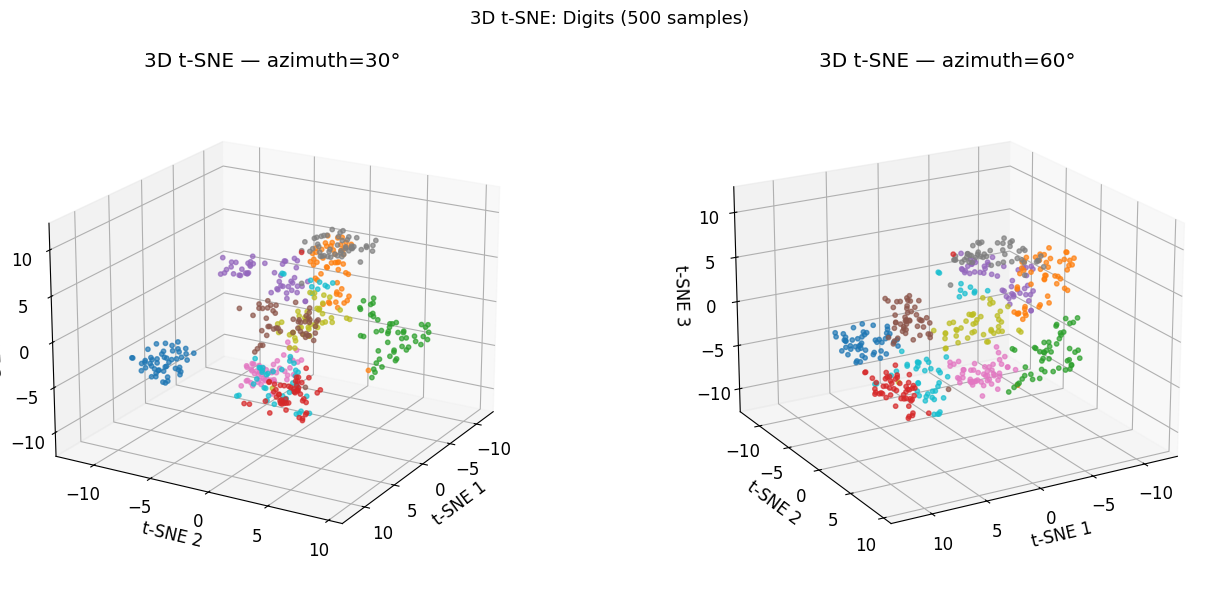

In [25]:
# 3D t-SNE on digits

tsne_3d = TSNE(n_components=3, perplexity=30, init='pca', random_state=42, n_iter=1000)
X_3d = tsne_3d.fit_transform(X_digits_scaled[:500])
y_3d = y_digits[:500]

fig = plt.figure(figsize=(14, 6))

for angle in [30, 60]:
    ax = fig.add_subplot(1, 2, [30,60].index(angle)+1, projection='3d')
    for digit in range(10):
        mask = y_3d == digit
        ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                   c=[cmap(digit)], s=10, alpha=0.7)
    ax.view_init(elev=20, azim=angle)
    ax.set_title(f"3D t-SNE — azimuth={angle}°")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2"); ax.set_zlabel("t-SNE 3")

fig.suptitle("3D t-SNE: Digits (500 samples)", fontsize=13)
plt.tight_layout()
plt.show()


## 17. t-SNE on Text/Embedding Data (Simulated)

In practice, t-SNE is frequently applied to:
- Word2Vec / GloVe / FastText embeddings (300D)
- BERT sentence embeddings (768D)
- Image feature vectors from CNNs

Let's simulate a 300-dimensional word embedding scenario.


Simulated embedding shape: (50, 300)


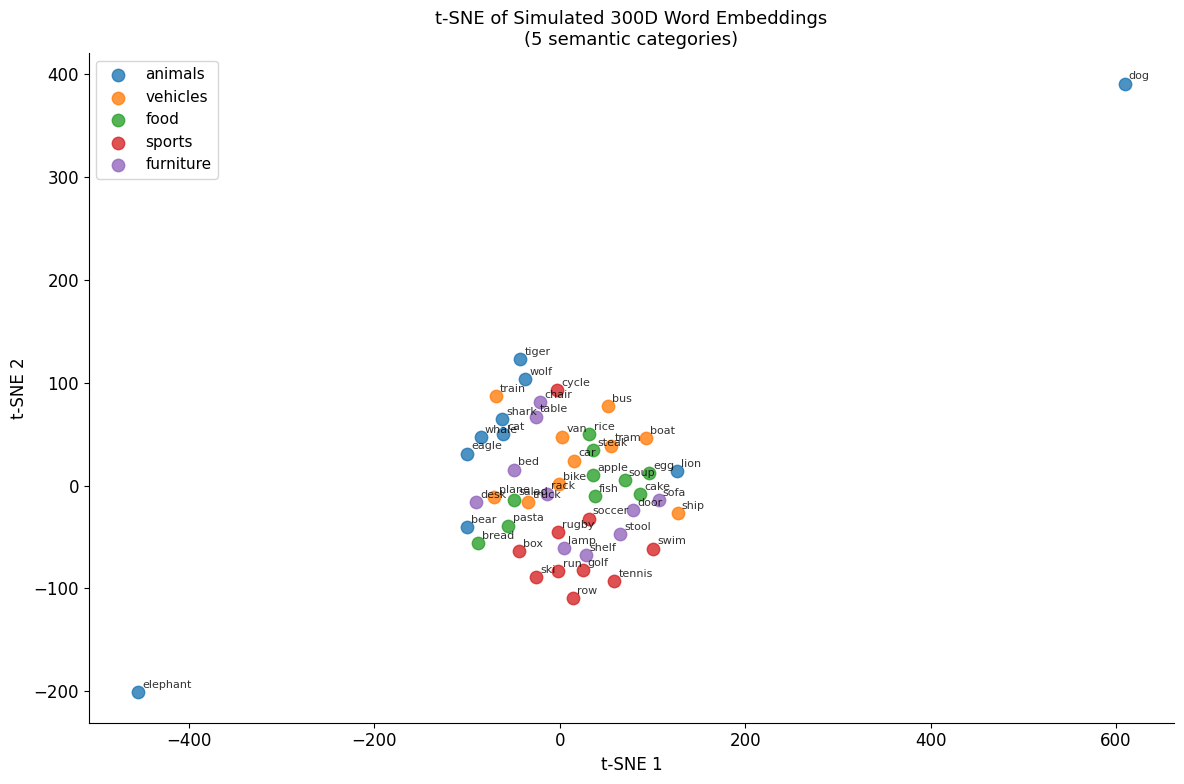

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Simulate word category embeddings (300D)

np.random.seed(99)
categories = {
    'animals':   (np.array([1, 0, 0, 0, 0] + [0]*295), 0),
    'vehicles':  (np.array([0, 1, 0, 0, 0] + [0]*295), 1),
    'food':      (np.array([0, 0, 1, 0, 0] + [0]*295), 2),
    'sports':    (np.array([0, 0, 0, 1, 0] + [0]*295), 3),
    'furniture': (np.array([0, 0, 0, 0, 1] + [0]*295), 4),
}

X_embed = []
y_embed = []
word_labels = []

words = {
    'animals':   ['dog','cat','lion','tiger','elephant','whale','eagle','shark','bear','wolf'],
    'vehicles':  ['car','bus','train','plane','boat','truck','bike','ship','tram','van'],
    'food':      ['apple','bread','rice','steak','pasta','salad','soup','fish','egg','cake'],
    'sports':    ['soccer','tennis','swim','rugby','golf','ski','box','run','cycle','row'],
    'furniture': ['chair','table','sofa','lamp','bed','desk','shelf','door','stool','rack'],
}

for cat, (center, label) in categories.items():
    for word in words[cat]:
        noise = np.random.randn(300) * 0.3
        vec = center.astype(float) + noise
        X_embed.append(vec)
        y_embed.append(label)
        word_labels.append(word)

X_embed = np.array(X_embed)
y_embed = np.array(y_embed)

cat_names = list(categories.keys())
print("Simulated embedding shape:", X_embed.shape)

# t-SNE
tsne_emb = TSNE(
    n_components=2,
    perplexity=8,
    init='pca',
    random_state=42,
    max_iter=2000   # ✅ FIXED
)

X_emb_2d = tsne_emb.fit_transform(X_embed)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors_e = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']

for label, cat in enumerate(cat_names):
    mask = y_embed == label
    
    ax.scatter(
        X_emb_2d[mask, 0],
        X_emb_2d[mask, 1],
        c=colors_e[label],
        s=80,
        label=cat,
        alpha=0.8
    )
    
    indices = np.where(y_embed == label)[0]
    for i, (x, y) in enumerate(X_emb_2d[mask]):
        word = word_labels[indices[i]]
        ax.annotate(
            word,
            (x, y),
            fontsize=8,
            alpha=0.8,
            xytext=(3, 3),
            textcoords='offset points'
        )

# ✅ FIXED title
ax.set_title("t-SNE of Simulated 300D Word Embeddings\n(5 semantic categories)", fontsize=13)

ax.legend(fontsize=11)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

## 18. Reproducibility and Seed Management

t-SNE is non-deterministic by default.  
Always set `random_state` for reproducibility.  
When presenting results to others, always report your random seed.


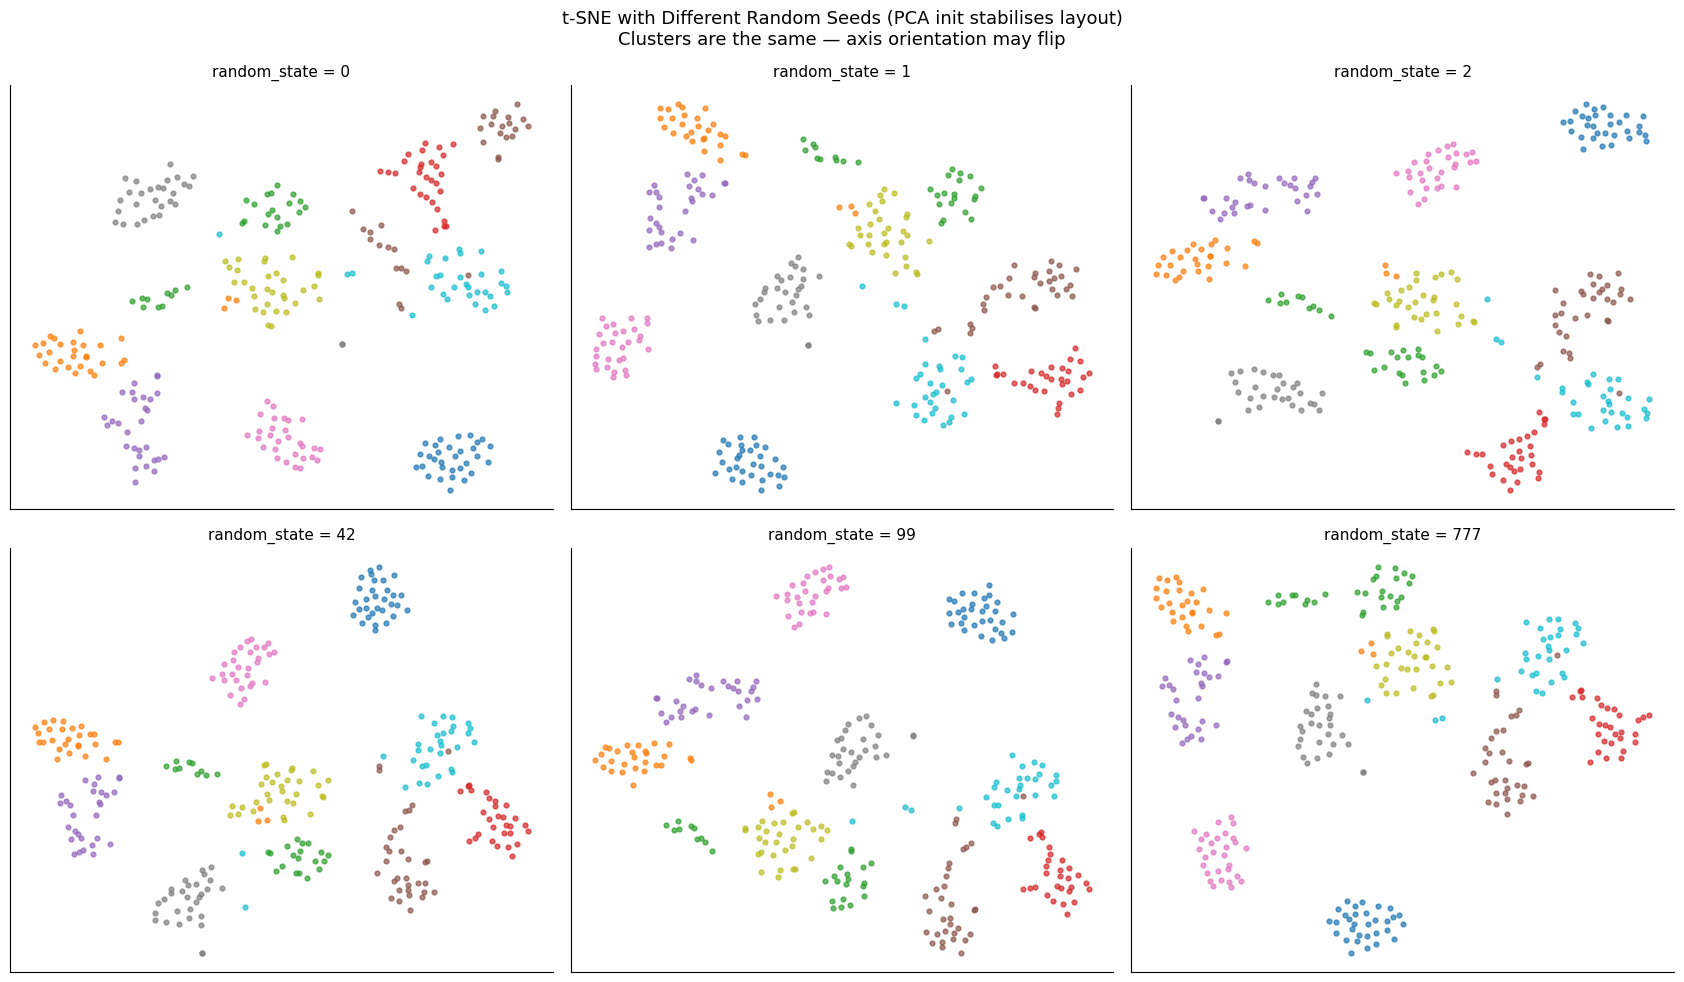

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Show variability with different seeds

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

X_rep = X_digits_scaled[:300]
y_rep = y_digits[:300]

for i, seed in enumerate([0, 1, 2, 42, 99, 777]):
    tsne_rep = TSNE(
        n_components=2,
        perplexity=30,
        init='pca',
        random_state=seed,
        learning_rate='auto',
        max_iter=1000   # ✅ FIXED
    )
    
    X_r = tsne_rep.fit_transform(X_rep)
    ax = axes[i // 3][i % 3]

    for digit in range(10):
        mask = y_rep == digit
        ax.scatter(
            X_r[mask, 0],
            X_r[mask, 1],
            c=[cmap(digit)],
            s=12,
            alpha=0.7
        )

    ax.set_title(f"random_state = {seed}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

# ✅ FIXED suptitle
fig.suptitle(
    "t-SNE with Different Random Seeds (PCA init stabilises layout)\n"
    "Clusters are the same — axis orientation may flip",
    fontsize=13
)

plt.tight_layout()
plt.show()

## 19. Scalability — t-SNE on Large Datasets

Standard t-SNE is O(n² log n) — slow beyond ~10K samples.

### Solutions:
1. **Barnes-Hut t-SNE** (`method='barnes_hut'`, default): O(n log n), handles ~50K
2. **PCA pre-reduction**: always do this before t-SNE for high-D data
3. **Sample first**: for >50K points, sample a representative subset
4. **UMAP**: better scalability if you need >50K points


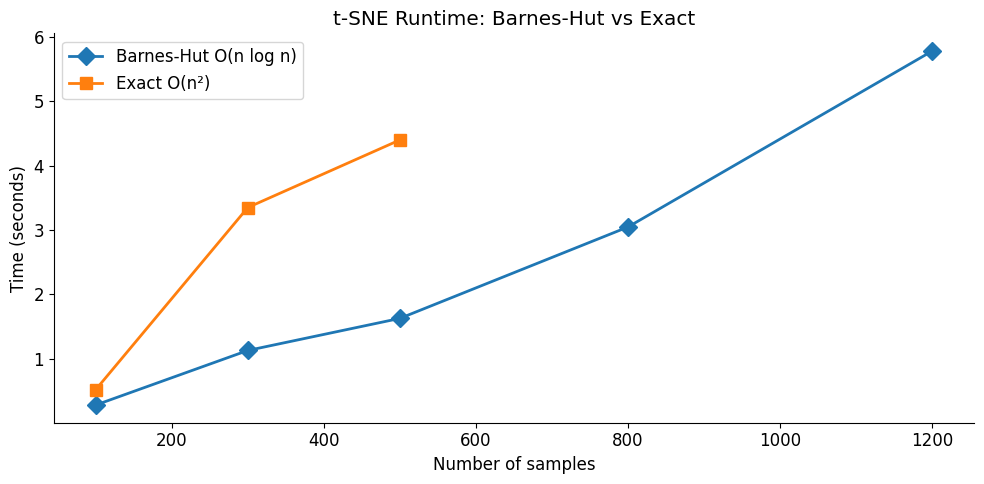

In [30]:
# Benchmark Barnes-Hut vs exact t-SNE

import time

sizes = [100, 300, 500, 800, 1200]
times_bh   = []
times_exact = []

for n in sizes:
    Xn = X_digits_scaled[:n]
    t0 = time.time()
    TSNE(n_components=2, perplexity=30, method='barnes_hut',
         init='pca', random_state=0, n_iter=500).fit_transform(Xn)
    times_bh.append(time.time() - t0)

    if n <= 500:
        t0 = time.time()
        TSNE(n_components=2, perplexity=30, method='exact',
             init='pca', random_state=0, n_iter=500).fit_transform(Xn)
        times_exact.append((n, time.time() - t0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sizes, times_bh, 'D-', color='tab:blue', ms=9, lw=2, label='Barnes-Hut O(n log n)')
if times_exact:
    sizes_ex, t_ex = zip(*times_exact)
    ax.plot(sizes_ex, t_ex, 's-', color='tab:orange', ms=9, lw=2, label='Exact O(n²)')

ax.set_xlabel("Number of samples")
ax.set_ylabel("Time (seconds)")
ax.set_title("t-SNE Runtime: Barnes-Hut vs Exact")
ax.legend()
plt.tight_layout()
plt.show()


## 20. Complete Best-Practice Pipeline

This is the production-ready recipe for using t-SNE correctly:

```
Raw high-D data
    ↓
StandardScaler  (mandatory)
    ↓
PCA(n_components=50)  (if dims > 50)
    ↓
TSNE(perplexity=30–50, init='pca', n_iter=1000+, random_state=<fixed>)
    ↓
2D/3D embedding
    ↓
Plot + colour by known labels or cluster assignments
```


PCA 50 components: 98.3% variance retained
Final KL divergence: 0.7892


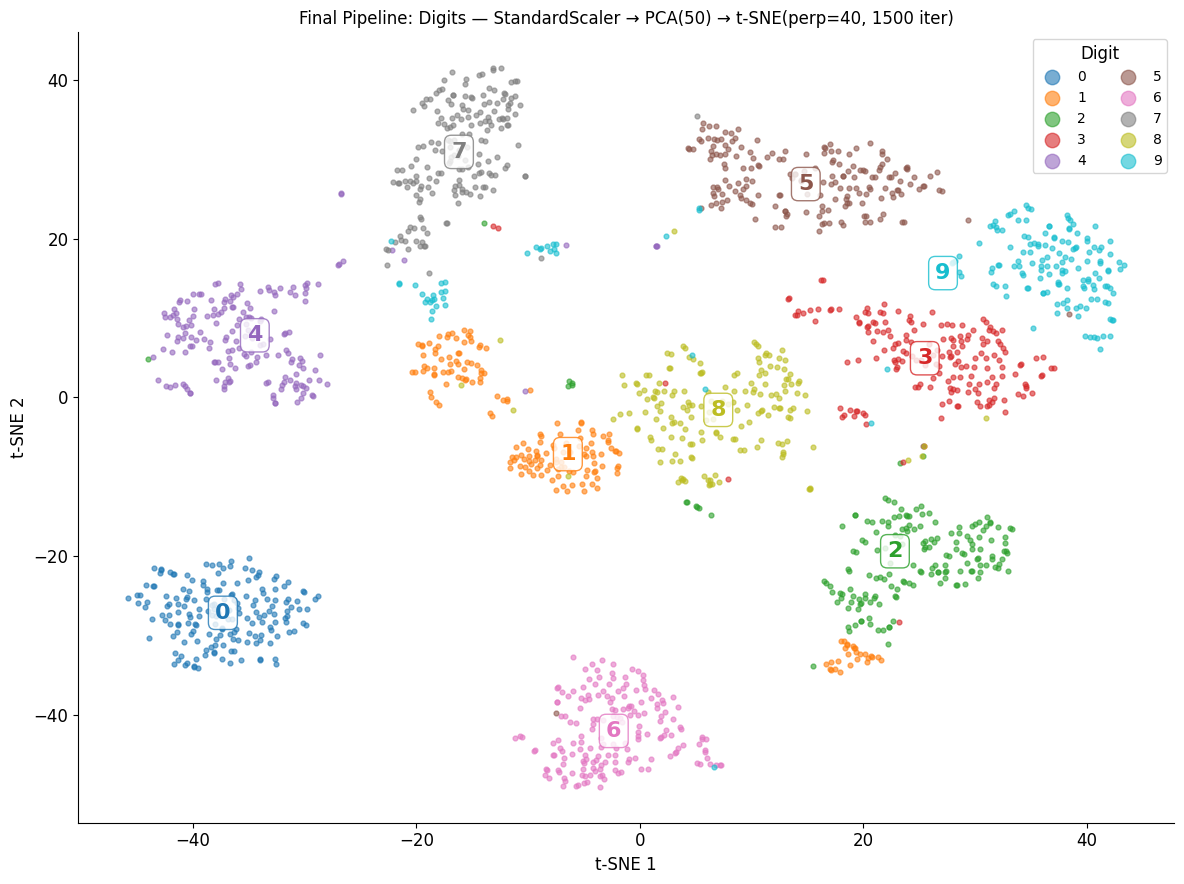

In [31]:
# Full pipeline — Digits dataset

from sklearn.pipeline import Pipeline

# Step 1: Scale
scaler = StandardScaler()
X_pipe = scaler.fit_transform(digits.data)

# Step 2: PCA pre-reduction
pca_pre = PCA(n_components=50, random_state=42)
X_pca_pre = pca_pre.fit_transform(X_pipe)
var_kept = pca_pre.explained_variance_ratio_.sum()
print(f"PCA 50 components: {var_kept*100:.1f}% variance retained")

# Step 3: t-SNE
tsne_final = TSNE(n_components=2, perplexity=40, learning_rate='auto',
                  init='pca', random_state=42, n_iter=1500,
                  n_jobs=-1 if hasattr(TSNE, 'n_jobs') else 1)
X_final = tsne_final.fit_transform(X_pca_pre)

print(f"Final KL divergence: {tsne_final.kl_divergence_:.4f}")

# Step 4: Plot with annotations
fig, ax = plt.subplots(figsize=(12, 9))
for digit in range(10):
    mask = digits.target == digit
    ax.scatter(X_final[mask, 0], X_final[mask, 1],
               c=[cmap(digit)], s=12, alpha=0.6, label=str(digit))
    cx = X_final[mask, 0].mean()
    cy = X_final[mask, 1].mean()
    ax.text(cx, cy, str(digit), fontsize=16, fontweight='bold',
            color=cmap(digit), ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=cmap(digit)))

ax.set_title("Final Pipeline: Digits — StandardScaler → PCA(50) → t-SNE(perp=40, 1500 iter)",
             fontsize=12)
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(title='Digit', loc='upper right', fontsize=10, markerscale=3, ncol=2)
plt.tight_layout()
plt.show()


## Summary

You now have a complete, practical understanding of t-SNE:

1. **Why it exists**: PCA is linear; real data lives on nonlinear manifolds
2. **Core algorithm**: Gaussian similarity in high-D → Student-t similarity in low-D → minimise KL divergence
3. **Student-t trick**: heavy tails push apart moderately-separated clusters, solving the crowding problem
4. **Perplexity**: effective neighbourhood size. Start at 30, sweep 5–100 on your data
5. **Learning rate**: use `'auto'`; only tune if embedding looks collapsed or exploded
6. **Initialisation**: always use `init='pca'` for stability
7. **What to trust**: local cluster membership. What NOT to trust: cluster sizes, inter-cluster distances
8. **Pipeline**: StandardScaler → PCA(50) → t-SNE with fixed random_state
9. **Scale limit**: Barnes-Hut handles ~50K; use UMAP beyond that

t-SNE is a visualisation tool, not a preprocessing step for ML models.  
Never feed t-SNE output directly into a classifier — it discards global structure and is not reproducible on new points.
